# Transfer learning & fine-tuning

**Author:** [fchollet](https://twitter.com/fchollet)<br>
**Date created:** 2020/04/15<br>
**Last modified:** 2023/06/25<br>
**Description:** Complete guide to transfer learning & fine-tuning in Keras.

## Setup

In [2]:
import numpy as np
import keras
from keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

## 소개

**전이 학습**은 한 문제에서 학습한 특성을 가져와서
새롭고 유사한 문제에 활용하는 것입니다. 예를 들어, 너구리를 식별하도록 학습된 모델의 특성은
너구리를 식별하도록 설계된 모델을 시작하는 데 유용할 수 있습니다.

전이 학습은 일반적으로 데이터셋의 데이터가 너무 적어
전체 모델을 처음부터 학습할 수 없는 작업에 사용됩니다.

딥 러닝 맥락에서 전이 학습의 가장 일반적인 구현은
다음과 같은 워크플로입니다.

1. 이전에 학습된 모델에서 계층을 가져옵니다.
2. 이후 학습 라운드에서 계층에 포함된 정보가 손상되지 않도록 계층을 고정합니다.

3. 고정된 계층 위에 새로운 학습 가능한 계층을 추가합니다. 이 계층은 기존 특성을
새로운 데이터셋에 대한 예측으로 변환하는 방법을 학습합니다.
4. 새 계층을 기존 데이터셋에 대해 학습합니다.

마지막 선택 단계는 **미세 조정**입니다. 이는 위에서 얻은 전체 모델(또는 일부)을 동결 해제하고 매우 낮은 학습률로 새 데이터에서 재학습하는 것입니다.
이를 통해 사전 학습된 특성을 새 데이터에 점진적으로 적용하여 의미 있는 개선을 달성할 수 있습니다.

먼저 대부분의 전이 학습 및 미세 조정 워크플로의 기반이 되는 Keras `학습 가능` API를 자세히 살펴보겠습니다.

그런 다음 ImageNet 데이터세트에서 사전 학습된 모델을 가져와 Kaggle "고양이 대 개" 분류 데이터세트에서 재학습하여 일반적인 워크플로를 보여드리겠습니다.

이 내용은
[Python을 활용한 딥 러닝](https://deeplearningwithpython.io/)
및 2016년 블로그 게시물
["매우 적은 데이터를 사용하여 강력한 이미지 분류 모델 구축"](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html)에서 발췌했습니다.

## 동결 계층: `trainable` 속성 이해하기

계층과 모델에는 세 가지 가중치 속성이 있습니다.

- `weights`는 계층의 모든 가중치 변수 목록입니다.
- `trainable_weights`는 학습 중 손실을 최소화하기 위해 (경사 하강법을 통해) 업데이트될 가중치 목록입니다.
- `non_trainable_weights`는 학습되지 않을 가중치 목록입니다.
일반적으로 이러한 속성은 순방향 전달 중에 모델에 의해 업데이트됩니다.

**예: `Dense` 계층에는 두 개의 학습 가능한 가중치(커널 및 바이어스)가 있습니다.**

In [5]:
layer = keras.layers.Dense(3)
layer.build((None, 4))  # Create the weights

print("weights:", len(layer.weights))
print("trainable_weights:", len(layer.trainable_weights))
print("non_trainable_weights:", len(layer.non_trainable_weights))

weights: 2
trainable_weights: 2
non_trainable_weights: 0


일반적으로 모든 가중치는 학습 가능한 가중치입니다. 학습 불가능한 가중치를 가진 유일한 내장 레이어는 `BatchNormalization` 레이어입니다. 이 레이어는 학습 불가능한 가중치를 사용하여
학습 중 입력의 평균과 분산을 추적합니다.
사용자 정의 레이어에서 학습 불가능한 가중치를 사용하는 방법은
[새 레이어를 처음부터 작성하는 가이드](/guides/making_new_layers_and_models_via_subclassing/)를 참조하세요.

**예: `BatchNormalization` 레이어에는 학습 가능한 가중치 2개와 학습 불가능한 가중치 2개가 있습니다.**

In [11]:
layer = keras.layers.BatchNormalization()
layer.build((None, 4))  # Create the weights

print(layer.weights)
print("weights:", len(layer.weights))
print(layer.trainable_weights)
print("trainable_weights:", len(layer.trainable_weights))
print(layer.non_trainable_weights)
print("non_trainable_weights:", len(layer.non_trainable_weights))

[<Variable path=batch_normalization_5/gamma, shape=(4,), dtype=float32, value=[1. 1. 1. 1.]>, <Variable path=batch_normalization_5/beta, shape=(4,), dtype=float32, value=[0. 0. 0. 0.]>, <Variable path=batch_normalization_5/moving_mean, shape=(4,), dtype=float32, value=[0. 0. 0. 0.]>, <Variable path=batch_normalization_5/moving_variance, shape=(4,), dtype=float32, value=[1. 1. 1. 1.]>]
weights: 4
[<Variable path=batch_normalization_5/gamma, shape=(4,), dtype=float32, value=[1. 1. 1. 1.]>, <Variable path=batch_normalization_5/beta, shape=(4,), dtype=float32, value=[0. 0. 0. 0.]>]
trainable_weights: 2
[<Variable path=batch_normalization_5/moving_mean, shape=(4,), dtype=float32, value=[0. 0. 0. 0.]>, <Variable path=batch_normalization_5/moving_variance, shape=(4,), dtype=float32, value=[1. 1. 1. 1.]>]
non_trainable_weights: 2


레이어와 모델에는 부울 속성 `trainable`도 있습니다. 이 속성의 값은 변경할 수 있습니다.
`layer.trainable`을 `False`로 설정하면 레이어의 모든 가중치가 학습 가능에서 학습 불가능으로 변경됩니다.
이를 레이어 "고정"이라고 합니다. 고정된 레이어의 상태는
학습 중에 업데이트되지 않습니다(`fit()`로 학습하거나
`trainable_weights`를 사용하여 기울기 업데이트를 적용하는 사용자 지정 루프를 사용하는 경우).

**예: `trainable`을 `False`로 설정**

In [12]:
layer = keras.layers.Dense(3)
layer.build((None, 4))  # Create the weights
layer.trainable = False  # Freeze the layer

print("weights:", len(layer.weights))
print("trainable_weights:", len(layer.trainable_weights))
print("non_trainable_weights:", len(layer.non_trainable_weights))

weights: 2
trainable_weights: 0
non_trainable_weights: 2


학습 가능한 가중치가 학습 불가능하게 되면 해당 값은 더 이상 학습 중에 업데이트되지 않습니다.

In [15]:
# Make a model with 2 layers
layer1 = keras.layers.Dense(3, activation="relu")
layer2 = keras.layers.Dense(3, activation="sigmoid")
model = keras.Sequential([keras.Input(shape=(3,)), layer1, layer2])

# Freeze the first layer
layer1.trainable = False

# Keep a copy of the weights of layer1 for later reference
initial_layer1_weights_values = layer1.get_weights()

# Train the model
model.compile(optimizer="adam", loss="mse")
model.fit(np.random.random((2, 3)), np.random.random((2, 3)))

# Check that the weights of layer1 have not changed during training
final_layer1_weights_values = layer1.get_weights()
np.testing.assert_allclose(
    initial_layer1_weights_values[0], final_layer1_weights_values[0]
)
np.testing.assert_allclose(
    initial_layer1_weights_values[1], final_layer1_weights_values[1]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step - loss: 0.1097


`layer.trainable` 속성을 `layer.__call__()`의 `training` 인수와 혼동하지 마십시오.
`layer.__call__()`는 계층이 순방향 패스를 추론 모드에서 실행할지 또는 학습 모드에서 실행할지 제어합니다.
자세한 내용은
[Keras FAQ](
https://keras.io/getting_started/faq/#whats-the-difference-between-the-training-argument-in-call-and-the-trainable-attribute)를 참조하십시오.

## `trainable` 속성의 재귀적 설정

모델이나 하위 레이어가 있는 레이어에 `trainable = False`를 설정하면
모든 하위 레이어도 학습 불가능 상태가 됩니다.

**예:**

In [16]:
inner_model = keras.Sequential(
    [
        keras.Input(shape=(3,)),
        keras.layers.Dense(3, activation="relu"),
        keras.layers.Dense(3, activation="relu"),
    ]
)

model = keras.Sequential(
    [
        keras.Input(shape=(3,)),
        inner_model,
        keras.layers.Dense(3, activation="sigmoid"),
    ]
)

model.trainable = False  # Freeze the outer model

assert inner_model.trainable == False  # All layers in `model` are now frozen
assert inner_model.layers[0].trainable == False  # `trainable` is propagated recursively

## 일반적인 전이 학습 워크플로

이를 통해 Keras에서 일반적인 전이 학습 워크플로를 구현하는 방법을 알 수 있습니다.

1. 기본 모델을 인스턴스화하고 사전 학습된 가중치를 로드합니다.
2. `trainable = False`를 설정하여 기본 모델의 모든 계층을 고정합니다.
3. 기본 모델의 하나(또는 여러) 계층 출력을 기반으로 새 모델을 만듭니다.

4. 새 데이터세트에서 새 모델을 학습합니다.

다음과 같은 더 가벼운 워크플로도 가능합니다.

1. 기본 모델을 인스턴스화하고 사전 학습된 가중치를 로드합니다.
2. 새 데이터세트를 실행하고 기본 모델의 하나(또는 여러) 계층 출력을 기록합니다.
이를 **특징 추출**이라고 합니다.
3. 해당 출력을 새롭고 더 작은 모델의 입력 데이터로 사용합니다.

두 번째 워크플로의 주요 장점은 학습 에포크당 한 번이 아니라, 기본 모델을 데이터에서 한 번만 실행할 수 있다는 것입니다. 따라서 훨씬 빠르고 저렴합니다.

하지만 두 번째 워크플로의 문제점은 학습 중에 새 모델의 입력 데이터를 동적으로 수정할 수 없다는 것입니다.
예를 들어 데이터 증강을 수행할 때 필요한 기능입니다.
전이 학습은 일반적으로 새 데이터 세트의 데이터가 너무 적어 전체 모델을 처음부터 학습할 수 없는 작업에 사용되며, 이러한 경우 데이터 증강이 매우 중요합니다. 따라서 다음에서는 첫 번째 워크플로에 중점을 두겠습니다.

Keras에서 첫 번째 워크플로는 다음과 같습니다.

먼저 사전 학습된 가중치를 사용하여 기본 모델을 인스턴스화합니다.

```python
base_model = keras.applications.Xception(
weights='imagenet', # ImageNet에서 사전 학습된 가중치를 로드합니다.
input_shape=(150, 150, 3),
include_top=False) # 맨 위에 ImageNet 분류기를 포함하지 않습니다.
```

그런 다음 기본 모델을 고정합니다.

```python
base_model.trainable = False
```

위에 새 모델을 만듭니다.

```python
inputs = keras.Input(shape=(150, 150, 3))
# 여기서는 `training=False`를 전달하여 기본 모델이 추론 모드에서 실행되도록 합니다.
# 이는 미세 조정에 중요하며, 몇 단락에서 자세히 배우게 될 것입니다.
#
x = base_model(inputs, training=False)
# `base_model.output_shape[1:]` 형태의 특징을 벡터로 변환
x = keras.layers.GlobalAveragePooling2D()(x)
# 단일 유닛을 가진 Dense 분류기(이진 분류)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
```

새로운 데이터로 모델을 학습시킵니다.

```python
model.compile(optimizer=keras.optimizers.Adam(),
loss=keras.losses.BinaryCrossentropy(from_logits=True),
metrics=[keras.metrics.BinaryAccuracy()])
model.fit(new_dataset, epochs=20, callbacks=..., validation_data=...)
```

## 미세 조정

모델이 새 데이터에 수렴하면 기본 모델의 전체 또는 일부를 동결 해제하고
매우 낮은 학습률로 전체 모델을 처음부터 끝까지 다시 학습해 볼 수 있습니다.

이 단계는 선택적인 마지막 단계로, 점진적인 개선 효과를 얻을 수 있습니다.
또한 빠른 과적합으로 이어질 수 있으니 유의해야 합니다.

이 단계는 동결된 레이어가 있는 모델이 수렴하도록 학습된 *후*에만 수행하는 것이 중요합니다.
무작위로 초기화된 학습 가능 레이어와 사전 학습된 특성을 포함하는 학습 가능 레이어를 혼합하면
무작위로 초기화된 레이어가 학습 중에 매우 큰 기울기 업데이트를 발생시켜 사전 학습된 특성을 손상시킵니다.

또한 이 단계에서는 매우 낮은 학습률을 사용하는 것이 중요합니다.
첫 번째 학습 라운드보다 훨씬 더 큰 모델을 일반적으로 매우 작은 데이터 세트에서 학습하기 때문입니다.
따라서 큰 가중치 업데이트를 적용하면 매우 빠르게 과적합될 위험이 있습니다. 여기서는 사전 학습된 가중치를 점진적으로 재적응시키기만 합니다.

전체 기본 모델의 미세 조정을 구현하는 방법은 다음과 같습니다.

```python
# 기본 모델 고정 해제
base_model.trainable = True

# 내부 레이어의 `trainable` 속성을 변경한 후에는 모델을 다시 컴파일하는 것이 중요합니다.
# 변경 사항이 반영되도록
# 해야 합니다.
model.compile(optimizer=keras.optimizers.Adam(1e-5), # 매우 낮은 학습률
loss=keras.losses.BinaryCrossentropy(from_logits=True),
metrics=[keras.metrics.BinaryAccuracy()])

# 종단 간 학습. 과적합되기 전에 중단하는 것이 중요합니다!
model.fit(new_dataset, epochs=10, callbacks=..., validation_data=...)
```

**`compile()` 및 `trainable`에 대한 중요 참고 사항**

모델에서 `compile()`을 호출하면 해당 모델의 동작이 "고정"됩니다. 즉, 모델이 컴파일될 당시 `trainable` 속성 값은 `compile`이 다시 호출될 때까지 해당 모델의 수명 동안 유지되어야 합니다. 따라서 `trainable` 값을 변경하는 경우, 변경 사항이 반영되도록 모델에서 `compile()`을 다시 호출해야 합니다.

**`BatchNormalization` 레이어에 대한 중요 참고 사항**

많은 이미지 모델에는 `BatchNormalization` 레이어가 포함되어 있습니다. 이 레이어는 모든 측면에서 특별한 경우입니다.
다음 몇 가지 사항을 명심해야 합니다.

- `BatchNormalization`에는 학습 중에 업데이트되는 두 개의 학습 불가능한 가중치가 포함되어 있습니다. 입력의 평균과 분산을 추적하는 변수입니다.
- `bn_layer.trainable = False`를 설정하면 `BatchNormalization` 계층은 추론 모드에서 실행되며 평균 및 분산 통계를 업데이트하지 않습니다. 이는 일반적으로 다른 계층에는 해당되지 않습니다.
[가중치 학습 가능성과 추론/학습 모드는 서로 직교하는 개념입니다](
https://keras.io/getting_started/faq/#whats-the-difference-between-the-training-argument-in-call-and-the-trainable-attribute).
하지만 `BatchNormalization` 계층의 경우 두 개념이 연관되어 있습니다.
- 미세 조정을 위해 `BatchNormalization` 계층이 포함된 모델을 고정 해제할 때는
기본 모델을 호출할 때 `training=False`를 전달하여 `BatchNormalization` 계층을 추론 모드로 유지해야 합니다.
그렇지 않으면 학습 불가능한 가중치에 적용된 업데이트가
모델이 학습한 내용을 갑자기 파괴합니다.

이 가이드의 마지막에 있는 엔드투엔드 예제에서 이 패턴이 실제로 어떻게 작동하는지 확인할 수 있습니다.

## 종단 간 예시: 고양이 대 개 데이터셋을 기반으로 이미지 분류 모델 미세 조정

이러한 개념을 확실히 이해하기 위해 구체적인 종단 간 전이 학습 및 미세 조정 예시를 살펴보겠습니다. ImageNet에서 사전 학습된 Xception 모델을 로드하고 Kaggle "고양이 대 개" 분류 데이터셋에 적용해 보겠습니다.

### 데이터 가져오기

먼저 TFDS를 사용하여 고양이 대 개 데이터셋을 가져오겠습니다. 자체 데이터셋이 있는 경우
`keras.utils.image_dataset_from_directory` 유틸리티를 사용하여 디스크에 있는 이미지 세트에서 유사한 레이블이 지정된 데이터셋 객체를 생성하고 클래스별 폴더에 저장할 수 있습니다.

전이 학습은 매우 작은 데이터셋을 사용할 때 가장 유용합니다. 데이터셋을 작게 유지하기 위해
원래 학습 데이터(25,000개 이미지)의 40%를 학습에, 10%를 검증에, 10%를 테스트에 사용합니다.

In [17]:
tfds.disable_progress_bar()

train_ds, validation_ds, test_ds = tfds.load(
    "cats_vs_dogs",
    # Reserve 10% for validation and 10% for test
    split=["train[:40%]", "train[40%:50%]", "train[50%:60%]"],
    as_supervised=True,  # Include labels
)

print(f"Number of training samples: {train_ds.cardinality()}")
print(f"Number of validation samples: {validation_ds.cardinality()}")
print(f"Number of test samples: {test_ds.cardinality()}")

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Number of training samples: 9305
Number of validation samples: 2326
Number of test samples: 2326


이는 훈련 데이터 세트의 처음 9개 이미지입니다. 보시다시피, 모두 크기가 다릅니다.

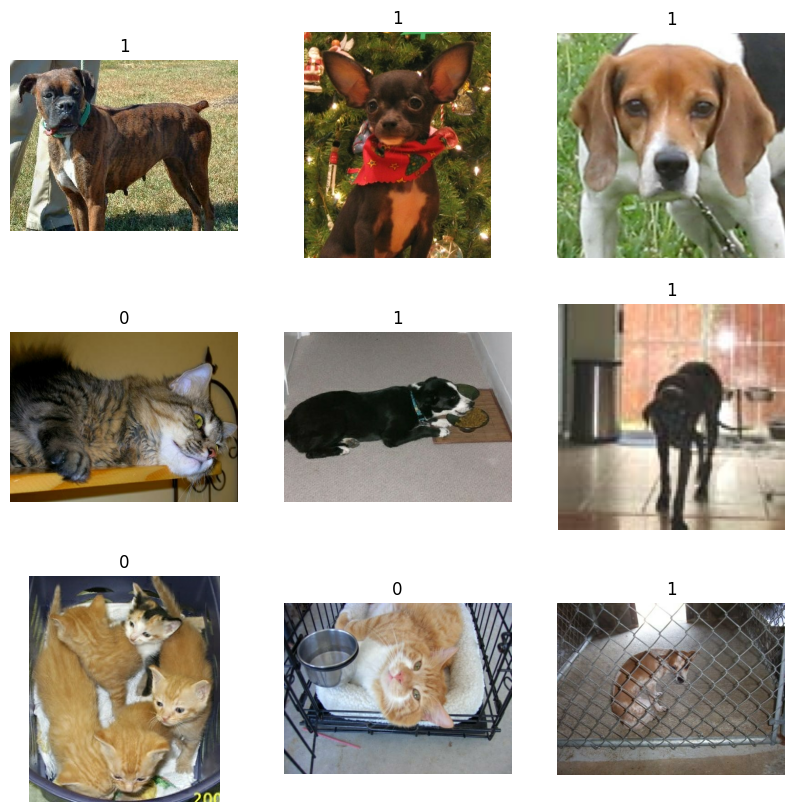

In [18]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")

또한 라벨 1은 "개"이고 라벨 0은 "고양이"인 것을 볼 수 있습니다.

### 데이터 표준화

원시 이미지는 다양한 크기를 가지고 있습니다. 또한 각 픽셀은 0에서 255 사이의 3개의 정수 값(RGB 레벨 값)으로 구성됩니다. 이는 신경망에 데이터를 공급하기에 적합하지 않습니다.
두 가지 작업을 수행해야 합니다.

- 고정된 이미지 크기로 표준화합니다. 150x150을 선택합니다.
- -1에서 1 사이의 픽셀 값을 정규화합니다. 이 작업은 모델 자체의 일부인 `Normalization` 레이어를 사용하여 수행합니다.

일반적으로 이미 전처리된 데이터를 사용하는 모델보다는 원시 데이터를 입력으로 사용하는 모델을 개발하는 것이 좋습니다.
그 이유는
모델이 전처리된 데이터를 필요로 하는 경우, 모델을 다른 곳(웹 브라우저, 모바일 앱)에서 사용하기 위해 내보낼 때마다
똑같은 전처리 파이프라인을 다시 구현해야 하기 때문입니다.
이 작업은 매우 까다로워집니다. 따라서 모델에 적용하기 전에 최소한의 전처리만 수행해야 합니다.

여기서는 데이터 파이프라인에서 이미지 크기를 조정합니다(심층 신경망은 연속된 데이터 배치만 처리할 수 있기 때문입니다). 그리고 모델을 생성할 때 모델의 일부로 입력 값 크기를 조정합니다.

이미지 크기를 150x150으로 조정해 보겠습니다.

In [19]:
resize_fn = keras.layers.Resizing(150, 150)

train_ds = train_ds.map(lambda x, y: (resize_fn(x), y))
validation_ds = validation_ds.map(lambda x, y: (resize_fn(x), y))
test_ds = test_ds.map(lambda x, y: (resize_fn(x), y))

### 무작위 데이터 증강 사용

대용량 이미지 데이터 세트가 없는 경우, 무작위 수평 뒤집기나 작은 무작위 회전과 같이 훈련 이미지에 무작위이면서도 현실적인 변환을 적용하여
인위적으로 샘플 다양성을 도입하는 것이 좋습니다.
이렇게 하면
모델이 훈련 데이터의 다양한 측면에 노출되는 동시에 과적합을 늦추는 데 도움이 됩니다.

In [20]:
augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]


def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x


train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

데이터를 일괄 처리하고 프리페칭을 사용하여 로딩 속도를 최적화해 보겠습니다.

In [21]:
from tensorflow import data as tf_data

batch_size = 64

train_ds = train_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
validation_ds = validation_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
test_ds = test_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()

다양한 무작위 변환 후 첫 번째 배치의 첫 번째 이미지가 어떻게 보이는지 시각화해 보겠습니다.

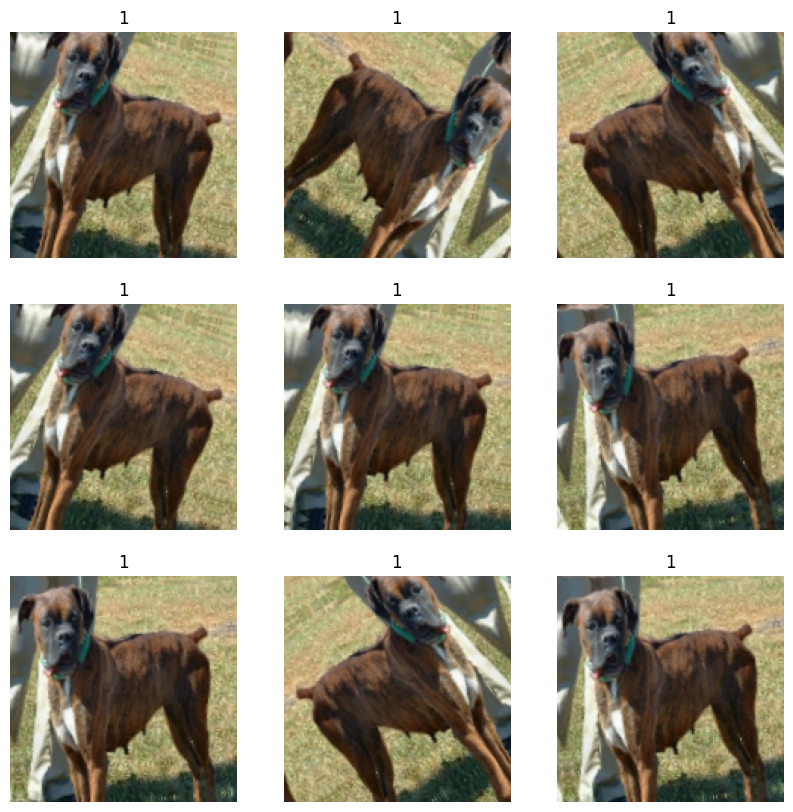

In [22]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(np.expand_dims(first_image, 0))
        plt.imshow(np.array(augmented_image[0]).astype("int32"))
        plt.title(int(labels[0]))
        plt.axis("off")

## 모델 구축

이제 앞서 설명한 청사진을 따르는 모델을 구축해 보겠습니다.

참고:

- 입력 값(초기에는 `[0, 255]` 범위)을 `[-1, 1]` 범위로 조정하기 위해 `Rescaling` 레이어를 추가합니다.

- 정규화를 위해 분류 레이어 앞에 `Dropout` 레이어를 추가합니다.
- 기본 모델을 호출할 때 `training=False`를 전달하여 추론 모드로 실행되도록 합니다.
이렇게 하면 미세 조정을 위해 기본 모델을 고정 해제한 후에도 배치 정규화 통계가 업데이트되지 않습니다.

In [23]:
base_model = keras.applications.Xception(
    weights="imagenet",  # Load weights pre-trained on ImageNet.
    input_shape=(150, 150, 3),
    include_top=False,
)  # Do not include the ImageNet classifier at the top.

# Freeze the base_model
base_model.trainable = False

# Create new model on top
inputs = keras.Input(shape=(150, 150, 3))

# Pre-trained Xception weights requires that input be scaled
# from (0, 255) to a range of (-1., +1.), the rescaling layer
# outputs: `(inputs * scale) + offset`
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1)
x = scale_layer(inputs)

# 기본 모델에는 배치 정규화(batchnorm) 계층이 포함되어 있습니다. 미세 조정을 위해 기본 모델을 고정 해제할 때 이 계층들을 추론 모드로 유지해야 하므로
# 여기서는 기본 모델이 추론 모드로 실행되도록 합니다.
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # Regularize with dropout
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_6 (InputLayer)  │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 5, 5, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_13 (Dense)            │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

## Train the top layer

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy()],
)

epochs = 2
print("Fitting the top layer of the model")
model.fit(train_ds, epochs=epochs, validation_data=validation_ds)

Fitting the top layer of the model
Epoch 1/2
146/146 ━━━━━━━━━━━━━━━━━━━━ 118s 633ms/step - binary_accuracy: 0.8734 - loss: 0.2745 - val_binary_accuracy: 0.9652 - val_loss: 0.0877
Epoch 2/2
146/146 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - binary_accuracy: 0.9427 - loss: 0.1331 - val_binary_accuracy: 0.9695 - val_loss: 0.0791


## 전체 모델에 대한 미세 조정을 한 번 진행합니다.

마지막으로, 기본 모델을 동결 해제하고 낮은 학습률로 전체 모델을 종단 간 학습해 보겠습니다.

중요한 점은 기본 모델이 학습 가능해지더라도 여전히 추론 모드로 실행된다는 것입니다.
모델을 빌드할 때 호출할 때 `training=False`를 전달했기 때문입니다.
즉, 내부의 배치 정규화 계층은 배치 통계를 업데이트하지 않습니다.
만약 업데이트한다면, 지금까지 모델이 학습한 표현을 망가뜨릴 것입니다.

In [26]:
# base_model을 고정 해제합니다. 호출 시 `training=False`를 전달했기 때문에 추론 모드에서 계속 실행됩니다.
# 즉,
# 배치 정규화 계층은 배치 통계를 업데이트하지 않습니다.
# 이렇게 하면 배치 정규화 계층이 지금까지 수행한 모든 학습을 취소하지 않습니다.
base_model.trainable = True
model.summary(show_trainable=True)

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # Low learning rate
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy()],
)

epochs = 1
print("Fitting the end-to-end model")
model.fit(train_ds, epochs=epochs, validation_data=validation_ds)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_6 (InputLayer)  │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 5, 5, 2048)    │ 20,861,480 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_13 (Dense)            │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,809,001 (79.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting the end-to-end model
146/146 ━━━━━━━━━━━━━━━━━━━━ 145s 627ms/step - binary_accuracy: 0.8590 - loss: 0.3602 - val_binary_accuracy: 0.9626 - val_loss: 0.1027


After 10 epochs, fine-tuning gains us a nice improvement here.
Let's evaluate the model on the test dataset:

In [27]:
print("Test dataset evaluation")
model.evaluate(test_ds)

Test dataset evaluation
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - binary_accuracy: 0.9582 - loss: 0.0964


[0.10722484439611435, 0.9565778374671936]